# Preparación de datos - G6

In [1]:
# Liberias
import pandas as pd
import numpy as np
from unidecode import unidecode
from datetime import date
import rasterio

## 1. Base de datos principal

- Casos confirmados de Dengue y Dengue grave mensual 2007 a 2024 agregado por municipio de residencia, obtenida del SISPRO del ministerio de salud.
- Codigo divipola y coordenadas obtenidas de datos del DANE
https://www.datos.gov.co/Mapas-Nacionales/DIVIPOLA-C-digos-municipios-geolocalizados/vafm-j2df/about_data
- Datos climaticos mesnuales de temperatura y precipitación obtenidos de archivos historicos de WorldClim
https://www.worldclim.org/data/monthlywth.html


In [2]:

#* Cargar datos de dengue
df = pd.read_csv('data/BaseDengue.csv', sep='|')

#* Remover numero y '-' en columnas Pais, Departamento y Municipio, y conversión a minusculas
cls = ['País', 'Departamento', 'Municipio']
for c in cls:
    df[c] = df[c].apply(lambda x: unidecode(x.split('-')[-1].strip().lower()))
df.rename(columns={'Año Epidemiologico': 'Year'}, inplace=True)
df.columns = [unidecode(c) for c in df.columns]

#* Eliminar pais no definido
df = df[df['Pais'] != 'no definido']

#* Eliminar municipios sin informacion
[i for i in df['Municipio'].unique() if 'sin informacion' in i]
df = df[~df['Municipio'].str.contains('sin informacion')]

#* Reordenar columnas
df = df.melt(
    id_vars=['Pais', 'Departamento', 'Municipio', 'Year'], # Columnas que se mantienen fijas
    var_name='Mes',              # Nombre para la nueva columna con los meses
    value_name='CasosConfirmados' # Nombre para la columna con los valores
)

#* leer archivo divipola
divipola = pd.read_excel('data/Listados_DIVIPOLA.xlsx', sheet_name='Municipios', skiprows=10, skipfooter=10)
divipola
divipola.columns = ['CodigoDepartamento', 'Departamento', 'CodigoMunicipio',
                    'Municipio',
                    'TipoMunicipio', 'Longitud', 'Latitud', 'Nota']

divipola.drop(columns=['Nota', 'CodigoDepartamento'], inplace=True)


#* decode Departamento, Municipio y TipoMunicipio
divipola['Departamento'] = divipola['Departamento'].apply(lambda x: unidecode(x.strip().lower()))
divipola['Municipio'] = divipola['Municipio'].apply(lambda x: unidecode(x.strip().lower()))
divipola['TipoMunicipio'] = divipola['TipoMunicipio'].apply(lambda x: unidecode(x.strip().lower()))

#* Corrección y estandarización de nombres de municipios en df para que coincidan con divipola
renamer = {
    'putumayo': {'leguizamo': 'puerto leguizamo'},
    'cauca': {'sotara': 'sotara paispamba',
              'piendamo': 'piendamo - tunia',
              'lopez': 'lopez de micay'},
    'magdalena': {'cerro san antonio': 'cerro de san antonio',
                  'chibolo': 'chivolo'},
    'antioquia': {'santafe de antioquia': 'santa fe de antioquia',
                  'san pedro': 'san pedro de uraba',
                  'san vicente': 'san vicente ferrer',
                  'don matias': 'donmatias'},
    'cordoba': {'san andres sotavento': 'san andres de sotavento',
                'purisima': 'purisima de la concepcion'},
    'guainia': {
                'mapiripana': 'mapiripan',
                'barranco minas': 'barrancominas'},
    'valle del cauca': {'cali': 'santiago de cali'},
    'cundinamarca': {'san juan de rio seco': 'san juan de rioseco'},
    'bolivar': {'cartagena': 'cartagena de indias',
                'mompos': 'santa cruz de mompox'},
    'sucre': {'tolu viejo': 'santiago de tolu'},
    'narino': {'cuaspud': 'cuaspud carlosama'},
    'tolima': {'mariquita': 'san sebastian de mariquita'},
    'amazonas': {'parana': 'miriti - parana'},
    'norte de santander': {'cucuta': 'san jose de cucuta'},
    'cesar': {'manaure': 'manaure balcon del cesar'},
    'vaupes': {'papunaua': 'papunahua'},
    'choco': {'belen de bajira': 'nuevo belen de bajira'}}

#* rename in df using renamer
for dept, munis in renamer.items():
    for muni, new_muni in munis.items():
        df.loc[(df['Departamento'] == dept) & (df['Municipio'] == muni), 'Municipio'] = new_muni

#* check Departamento and Municipio combinations present in df but not in divipola
df_combinations = set(zip(df['Departamento'], df['Municipio']))
divipola_combinations = set(zip(divipola['Departamento'], divipola['Municipio']))
missing_combinations = df_combinations - divipola_combinations
missing_combinations

#* delete in df where Departamento and Municipio are equal
df = df[~df.apply(lambda x: (x['Departamento'], x['Municipio']) in missing_combinations, axis=1)]

#* merge df and divipola on Departamento and Municipio
df = df.merge(divipola, on=['Departamento', 'Municipio'], how='left', )

#* reorder columns, drop pais and save to csv
df.drop(columns=['Pais'], inplace=True)
df.drop_duplicates(inplace=True)
df = df[['CodigoMunicipio','Departamento', 'Municipio','TipoMunicipio', 'Longitud', 'Latitud', 'Year', 'Mes', 'CasosConfirmados']]

#* Agregar datos climaticos y de elevacion
df['key'] = df['Departamento'] + '_' + df['Municipio']

#* unique combinations for Longitud and Latitud
locs = df[['key','Longitud', 'Latitud']].drop_duplicates(ignore_index=True)

In [3]:

#* obtener elevacion usando rasterio
files = {'Elevacion':r'data\worldclim\wc2.1_2.5m_elev\wc2.1_2.5m_elev.tif',
         } #! Datos elevacion
         
resultados = {}
for var,file in files.items():
    resultados[var] = []
    with rasterio.open(file) as src:
        # src.sample expects an iterable of (x, y) coordinates
        # For geospatial data, x is Longitude and y is Latitude
        for index, row in locs.iterrows():
            coordinates = [(row['Longitud'], row['Latitud'])]
            sample_gen = src.sample(coordinates)
            
            for result in sample_gen:
            # result is an array of values for each band. 
            # WorldClim files typically have 1 band per file.
                resultados[var].append(result[0])


In [4]:
locs['Elevacion'] = resultados['Elevacion']
#* agregar elevacion a df usando key
df = df.merge(locs[['key', 'Elevacion']], on='key', how='left')


In [5]:

#* Obetner temperatura y precipitacion mensual
files = {'tmin':[r'data\worldclim\wc2.1_cruts4.09_2.5m_tmin_2000-2009',
                           r'data\worldclim\wc2.1_cruts4.09_2.5m_tmin_2010-2019',
                           r'data\worldclim\wc2.1_cruts4.09_2.5m_tmin_2020-2024'],
         'tmax':[r'data\worldclim\wc2.1_cruts4.09_2.5m_tmax_2000-2009',
                           r'data\worldclim\wc2.1_cruts4.09_2.5m_tmax_2010-2019',
                           r'data\worldclim\wc2.1_cruts4.09_2.5m_tmax_2020-2024'],
         'prec':[r'data\worldclim\wc2.1_cruts4.09_2.5m_prec_2000-2009',
                         r'data\worldclim\wc2.1_cruts4.09_2.5m_prec_2010-2019',
                         r'data\worldclim\wc2.1_cruts4.09_2.5m_prec_2020-2024']
        }


locs = df[['key','Longitud', 'Latitud', 'Year', 'Mes']].drop_duplicates(ignore_index=True)
# locs

In [6]:
parse_month = {'Enero': '01', 'Febrero': '02', 'Marzo': '03', 'Abril': '04', 'Mayo': '05', 'Junio': '06',
               'Julio': '07', 'Agosto': '08', 'Septiembre': '09', 'Octubre': '10', 'Noviembre': '11', 'Diciembre': '12'}

locs['Mes'] = locs['Mes'].apply(lambda x: parse_month[x])
df['Mes'] = df['Mes'].apply(lambda x: parse_month[x])
locs.sort_values(['Year', 'Mes'], inplace=True)
locs.reset_index(drop=True, inplace=True)
#* por cada combinacion año mes, abrir archivo y obtener datos climaticos por coordenada
y_m_combinations = locs[['Year', 'Mes']].drop_duplicates()
results = []
for var, folders in files.items():
    for y,m in y_m_combinations.itertuples(index=False):
        #* determinar carpeta a abrir segun año
        if y <= 2009:
            folder = folders[0]
        elif y <= 2019:
            folder = folders[1]
        else:
            folder = folders[2]
        
        file = f"{folder + '\\' + '_'.join(folder.split('\\')[-1].split('_')[:-1]) + f'_{y}-{m}.tif'}"
        with rasterio.open(file) as src:
            for index, row in locs[(locs['Year'] == y) & (locs['Mes'] == m)].iterrows():
                coordinates = [(row['Longitud'], row['Latitud'])]
                sample_gen = src.sample(coordinates)
                
                for result in sample_gen:
                    results.append((row['Longitud'], row['Latitud'], y, m, var, result[0]))
        

In [7]:
results_df = pd.DataFrame(results, columns=['Longitud', 'Latitud', 'Year', 'Mes', 'Variable', 'Valor'])
#* melt results_df para tener columnas separadas para cada variable
results_df = results_df.pivot_table(index=['Longitud', 'Latitud', 'Year', 'Mes'], columns='Variable', values='Valor').reset_index()
#* merge con df para agregar variables climaticas
df = df.merge(results_df, on=['Longitud', 'Latitud', 'Year', 'Mes'], how='left')

In [8]:

#* Rename cols prec, tmax y tmin a Precipitacion, TempMax y TempMin
df.rename(columns={'prec': 'Precipitacion', 'tmax': 'TempMax', 'tmin': 'TempMin'}, inplace=True)
#* drop key column
df.drop(columns=['key'], inplace=True)
#* save to csv
df.to_csv('data/dengue_data_v2.csv', index=False, sep='|')

In [9]:
df

,CodigoMunicipio,Departamento,Municipio,TipoMunicipio,Longitud,Latitud,Year,Mes,CasosConfirmados,Elevacion,Precipitacion,TempMax,TempMin
0,5001,antioquia,medellin,municipio,-75.581775,6.246631,2007,01,1.0,1609,66.900002,25.0,17.0
1,5001,antioquia,medellin,municipio,-75.581775,6.246631,2008,01,128.0,1609,88.599998,26.0,15.0
2,5001,antioquia,medellin,municipio,-75.581775,6.246631,2009,01,30.0,1609,137.500000,26.0,15.0
3,5001,antioquia,medellin,municipio,-75.581775,6.246631,2010,01,130.0,1609,18.400000,29.0,16.0
4,5001,antioquia,medellin,municipio,-75.581775,6.246631,2011,01,126.0,1609,110.900002,27.0,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
178900,99773,vichada,cumaribo,municipio,-69.795533,4.446352,2020,12,5.0,134,77.699997,33.0,23.0
178901,99773,vichada,cumaribo,municipio,-69.795533,4.446352,2021,12,1.0,134,75.099998,33.0,23.0
178902,99773,vichada,cumaribo,municipio,-69.795533,4.446352,2022,12,7.0,134,77.000000,32.0,22.0
178903,99773,vichada,cumaribo,municipio,-69.795533,4.446352,2023,12,8.0,134,79.599998,33.0,23.0


## Análisis exploratorio de datos

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 178905 entries, 0 to 178904
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   CodigoMunicipio   178905 non-null  int64  
 1   Departamento      178905 non-null  str    
 2   Municipio         178905 non-null  str    
 3   TipoMunicipio     178905 non-null  str    
 4   Longitud          178905 non-null  float64
 5   Latitud           178905 non-null  float64
 6   Year              178905 non-null  int64  
 7   Mes               178905 non-null  str    
 8   CasosConfirmados  178905 non-null  float64
 9   Elevacion         178905 non-null  int16  
 10  Precipitacion     178509 non-null  float32
 11  TempMax           178905 non-null  float32
 12  TempMin           178905 non-null  float32
dtypes: float32(3), float64(3), int16(1), int64(2), str(4)
memory usage: 19.6 MB


In [11]:
df.describe()

,CodigoMunicipio,Longitud,Latitud,Year,CasosConfirmados,Elevacion,Precipitacion,TempMax,TempMin
count,178905.000000,178905.000000,178905.000000,178905.000000,178905.000000,178905.000000,178509.000000,1.789050e+05,1.789050e+05
mean,40736.491658,-74.717321,5.877549,2015.757877,9.089690,942.509343,178.280899,-4.753353e+06,-4.753362e+06
std,26620.887593,1.562660,2.692488,5.105386,60.454656,843.037928,134.435547,1.009221e+08,1.009221e+08
min,5001.000000,-81.707181,-4.198950,2007.000000,0.000000,3.000000,0.100000,-2.147484e+09,-2.147484e+09
25%,17614.000000,-75.761120,4.270042,2011.000000,0.000000,128.000000,82.199997,2.500000e+01,1.500000e+01
50%,41020.000000,-74.879717,5.634545,2016.000000,1.000000,877.000000,153.600006,2.900000e+01,1.900000e+01
75%,68266.000000,-73.615965,7.847672,2020.000000,4.000000,1583.000000,243.399994,3.200000e+01,2.300000e+01
max,99773.000000,-66.963692,13.373185,2024.000000,5148.000000,3690.000000,1382.400024,3.800000e+01,2.800000e+01


In [12]:
#libs
## Librerías de visualización 
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import seaborn as sns

In [ ]:
# funciones para analisis exploratorio y visualizacion de datos

#* Análisis de correlación
def plot_correlation_map( df ):
    corr = df.corr()
    _ , ax = plt.subplots( figsize =( 12 , 10 ) )
    cmap = sns.diverging_palette( 220 , 10 , as_cmap = True )
    _ = sns.heatmap(
        corr, 
        cmap = cmap,
        square=True, 
        cbar_kws={ 'shrink' : .9 }, 
        ax=ax, 
        annot = True, 
        annot_kws = { 'fontsize' : 12 }
    )

def frecuencia_mensual_con_umbral(df, umbral=5000):
    #* frecuencia por meses y años en cundinamarca con años separados en diferentes subplots
    df_agrupado = df.groupby(['Year', 'Mes'])['CasosConfirmados'].sum().reset_index()
    df_agrupado = df_agrupado.sort_values(by=['Year', 'Mes'])

    # 2. Configuración del estilo
    sns.set_theme(style="whitegrid")

    # 3. Creación de la cuadrícula
    g = sns.FacetGrid(df_agrupado, col="Year", col_wrap=4, height=3, aspect=1.5, sharex=False, sharey=False)

    # 4. Gráfico principal (Línea de casos)
    g.map(sns.lineplot, "Mes", "CasosConfirmados", marker="o")

    # umbral
    g.refline(y=umbral, color="red", linestyle="--", linewidth=1.5, label="Umbral 5000")

    # 5. Ajustes finales
    g.set_axis_labels("Mes", "Total Casos")
    g.set_titles(col_template="Año {col_name}")
    g.fig.suptitle("Comportamiento Mensual vs Umbral de Referencia", y=1.02)

    g.add_legend()

    plt.show()

def frecuencia_mensual_con_umbral_v2(df, umbral=5000, anos_por_subplot=1):
    """
    Genera gráficos de línea para casos confirmados.
    
    Args:
        df: DataFrame con columnas 'Year', 'Mes', 'CasosConfirmados'.
        umbral: Valor para la línea horizontal de referencia.
        anos_por_subplot: Cantidad de años continuos a mostrar en cada gráfica (ej. 2 para pares de años).
    """
    
    # 1. Agrupación inicial
    df_agrupado = df.groupby(['Year', 'Mes'])['CasosConfirmados'].sum().reset_index()
    
    # 2. Crear columna 'Fecha' para tener un Eje X continuo
    # Es vital convertir a datetime para que al graficar 2 o 3 años seguidos, 
    # la línea continúe cronológicamente y no se superpongan los meses.
    df_agrupado['Fecha'] = pd.to_datetime(
        df_agrupado['Year'].astype(str) + '-' + df_agrupado['Mes'].astype(str) + '-01'
    )
    df_agrupado = df_agrupado.sort_values('Fecha')

    # 3. Definir los bloques de años (Periodos)
    min_year = df_agrupado['Year'].min()
    
    # Calculamos un índice de bloque: (AñoActual - AñoMinimo) // N
    df_agrupado['Bloque_Indice'] = (df_agrupado['Year'] - min_year) // anos_por_subplot
    
    # Generamos etiquetas legibles para los títulos (Ej: "2007-2008")
    def generar_etiqueta(row):
        inicio = min_year + (row['Bloque_Indice'] * anos_por_subplot)
        fin = inicio + anos_por_subplot - 1
        if anos_por_subplot == 1:
            return str(inicio)
        return f"{inicio} - {fin}"

    df_agrupado['Periodo'] = df_agrupado.apply(generar_etiqueta, axis=1)

    # 4. Configuración del estilo
    sns.set_theme(style="whitegrid")

    # 5. Creación de la cuadrícula
    # Usamos 'Periodo' en col, y aumentamos el 'aspect' (ancho) para que quepan mejor las fechas
    g = sns.FacetGrid(df_agrupado, col="Periodo", col_wrap=3, height=3.5, aspect=2, sharex=False, sharey=False)

    # 6. Gráfico principal
    # Usamos 'Fecha' en el eje X en lugar de 'Mes'
    g.map(sns.lineplot, "Fecha", "CasosConfirmados", marker="o")

    # Umbral
    g.refline(y=umbral, color="red", linestyle="--", linewidth=1.5, label=f"Umbral {umbral}")

    # 7. Ajustes finales
    g.set_axis_labels("Fecha", "Total Casos")
    g.set_titles(col_template="{col_name}")
    g.fig.suptitle(f"Comportamiento de Casos ({anos_por_subplot} años por gráfica)", y=1.02)

    # Rotación de fechas en el eje X para evitar solapamiento
    for ax in g.axes.flat:
        for label in ax.get_xticklabels():
            label.set_rotation(45)
            label.set_horizontalalignment('right')

    g.add_legend()
    plt.show()



Text(0.5, 1.0, 'Casos confirmados de dengue por año en Cundinamarca')

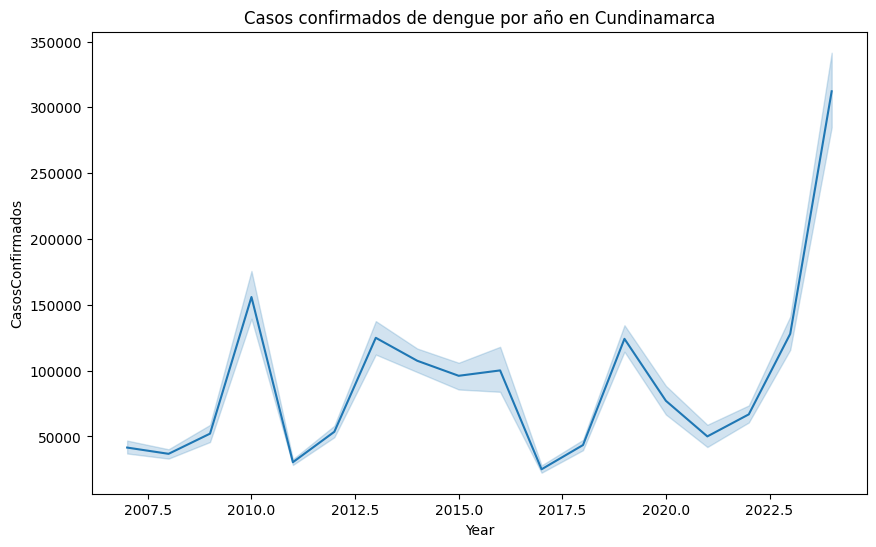

In [14]:
#* Casos confirmados por año
plt.figure(figsize=(10,6))
sns.lineplot(data=df, x='Year', y='CasosConfirmados', estimator='sum')
plt.title('Casos confirmados de dengue por año en Cundinamarca')

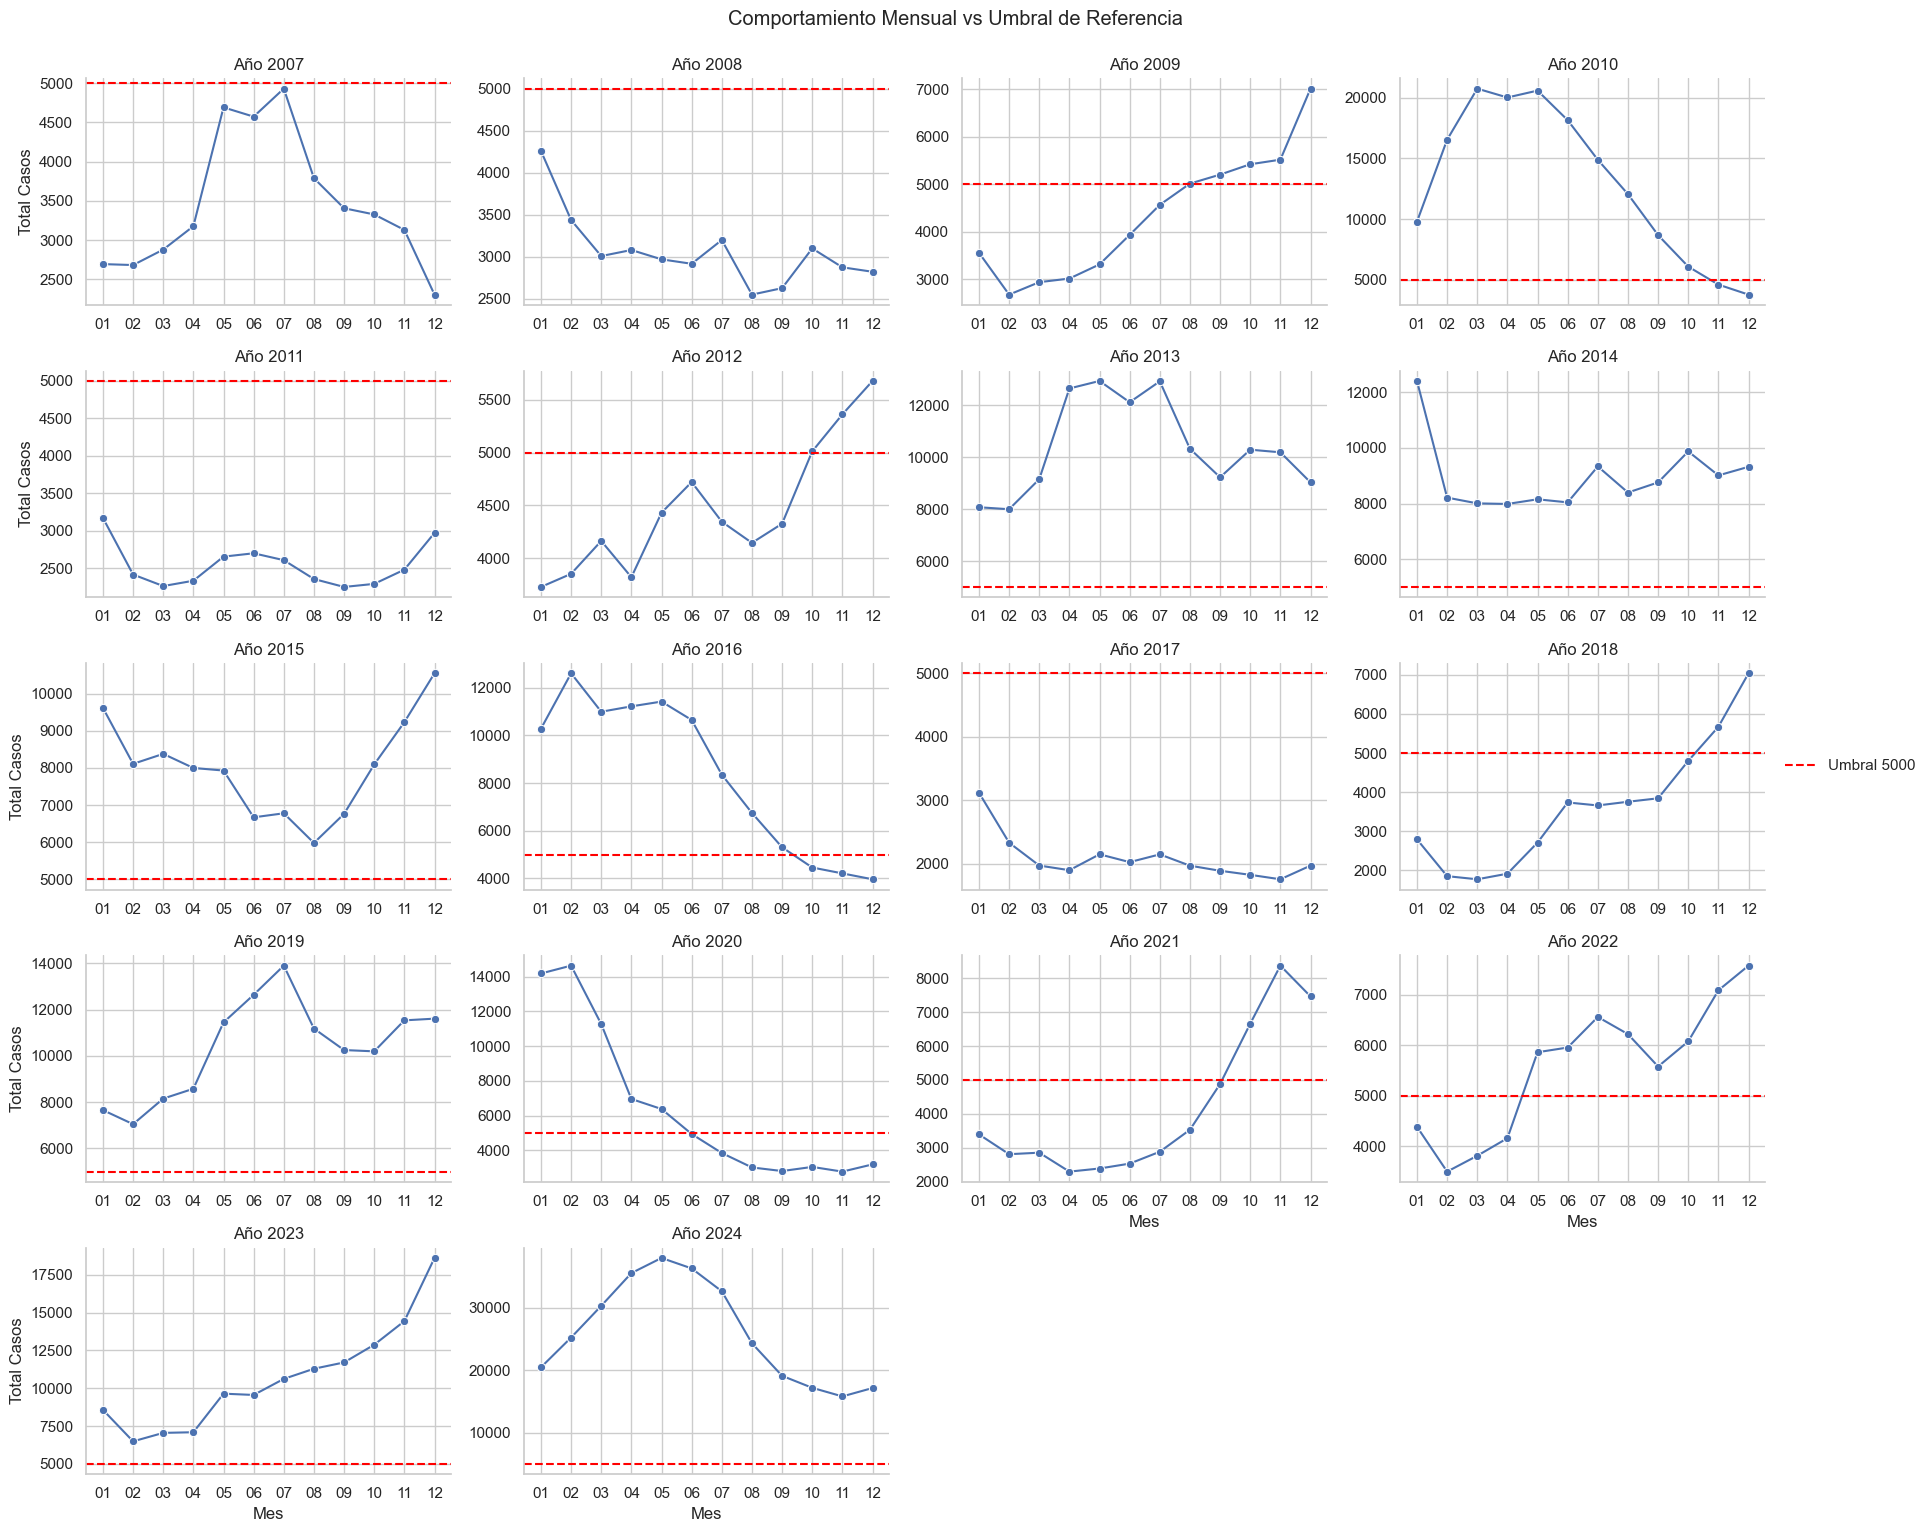

In [15]:
frecuencia_mensual_con_umbral(df)

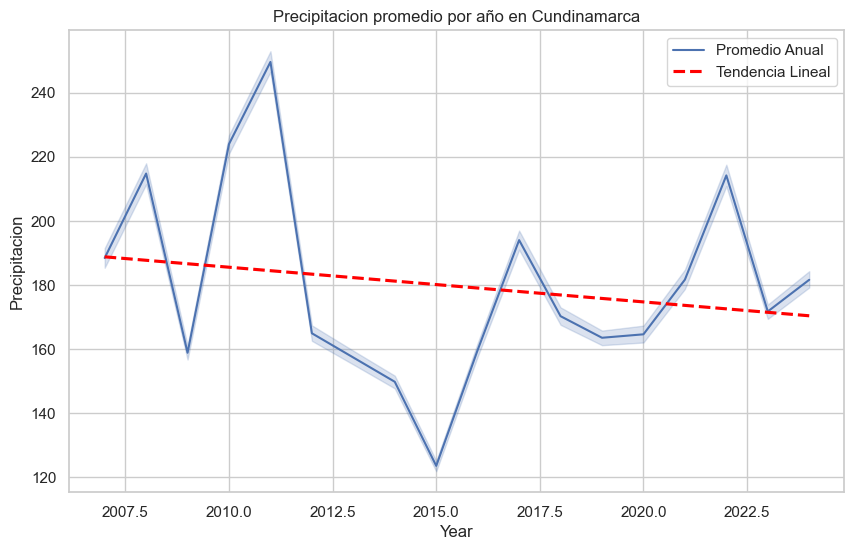

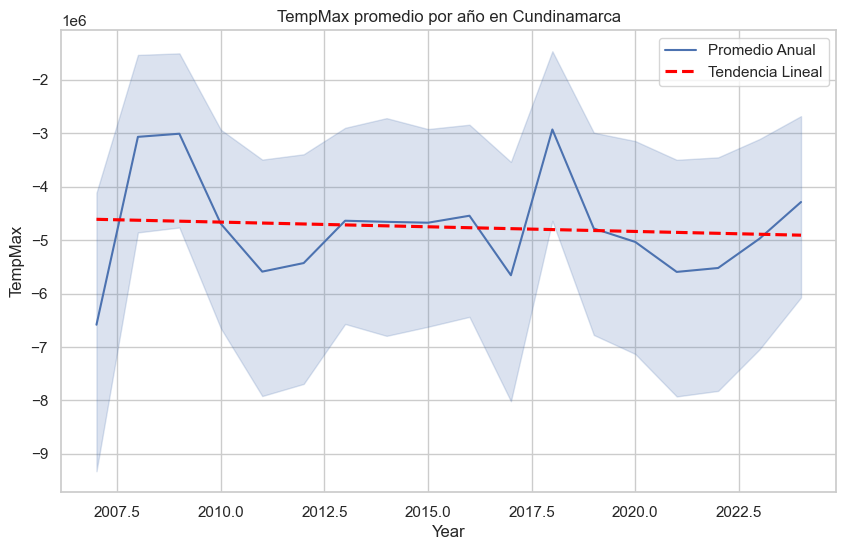

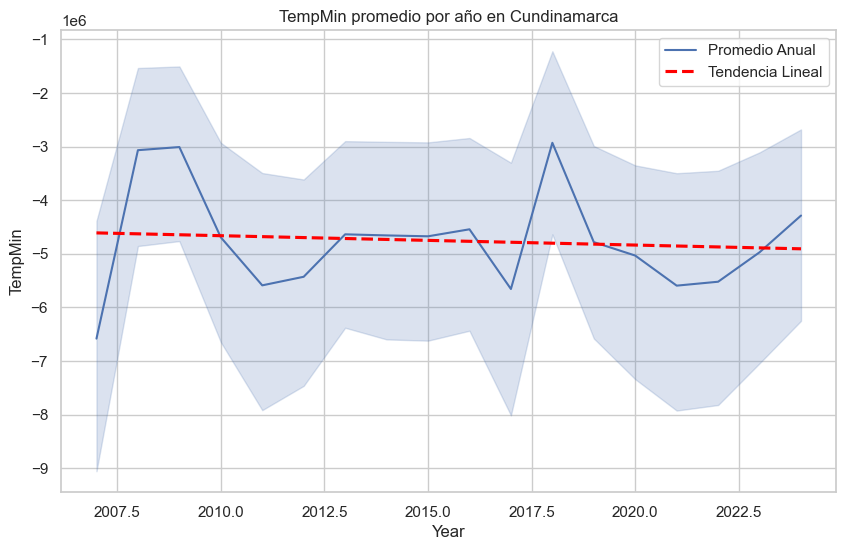

In [16]:
#* temperaturas y precipitacion promedio por año
cols = ['Precipitacion','TempMax','TempMin']
for col in cols:
    plt.figure(figsize=(10, 6))
    
    # 1. Tu gráfica original (Línea de promedios anuales)
    sns.lineplot(data=df, x='Year', y=col, estimator='mean', label='Promedio Anual')
    
    # 2. Preparar datos para la tendencia (Agrupamos por año para obtener el promedio)
    # Esto es necesario porque lineplot agrega internamente, pero para calcular la tendencia
    # necesitamos los puntos exactos (x, y) de esos promedios.
    df_trend = df.groupby('Year')[col].mean().reset_index()
    
    # 3. Graficar la línea de tendencia usando regplot
    # scatter=False evita que pinte los puntos de nuevo, solo queremos la línea
    # ci=None quita la sombra del intervalo de confianza (opcional, puedes dejarlo si prefieres)
    sns.regplot(data=df_trend, x='Year', y=col, scatter=False, color='red', line_kws={'linestyle':'--'}, label='Tendencia Lineal', ci=None)
    
    plt.title(f'{col} promedio por año en Cundinamarca')
    plt.legend()
    plt.show()



Text(0.5, 1.0, 'Casos confirmados de dengue por año en Cundinamarca')

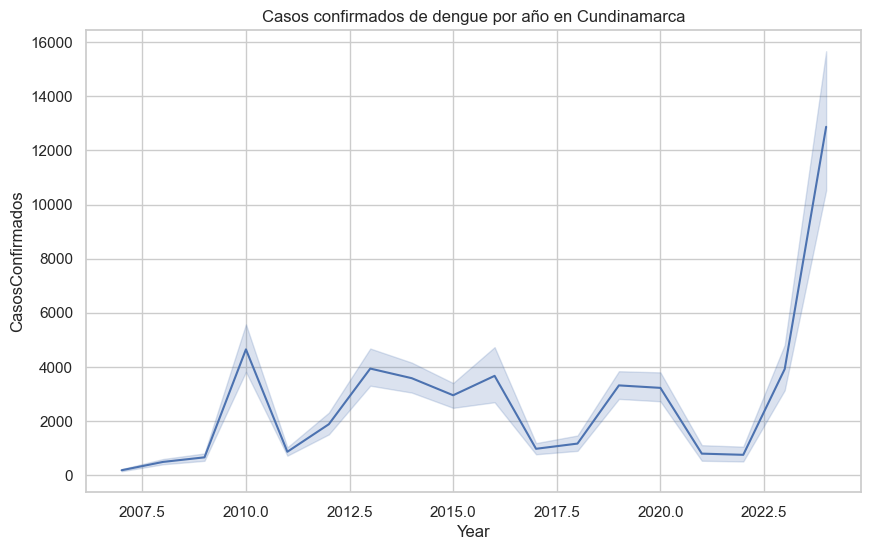

In [17]:
df_cund = df[df['Departamento'] == 'cundinamarca']

#* Casos confirmados por año
plt.figure(figsize=(10,6))
sns.lineplot(data=df_cund, x='Year', y='CasosConfirmados', estimator='sum')
plt.title('Casos confirmados de dengue por año en Cundinamarca')



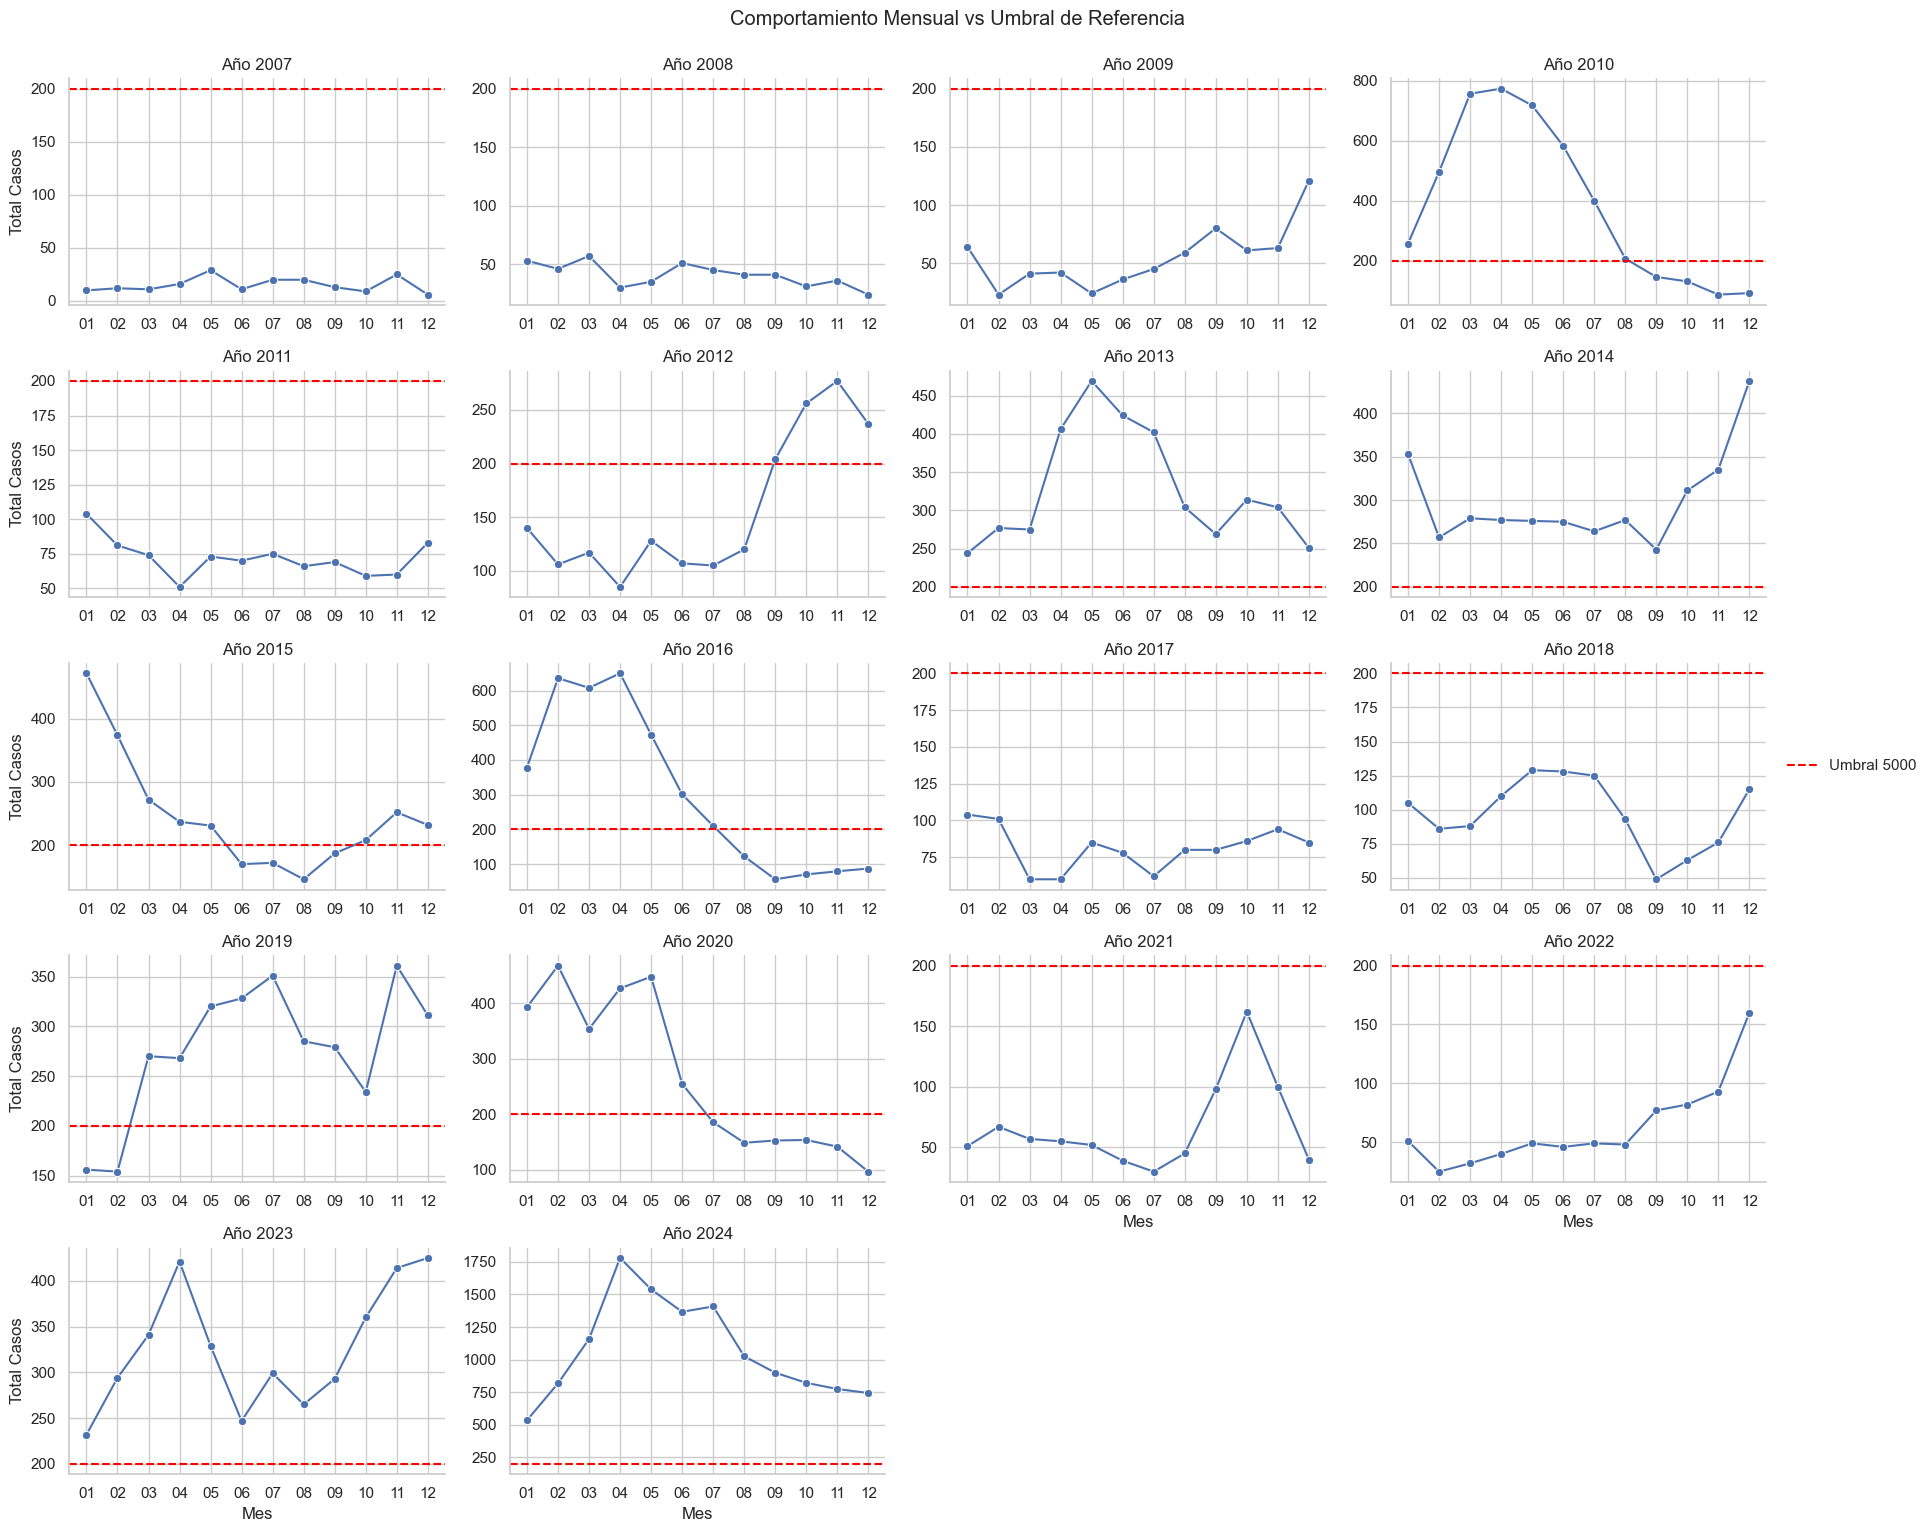

In [18]:
frecuencia_mensual_con_umbral(df_cund, umbral=200)

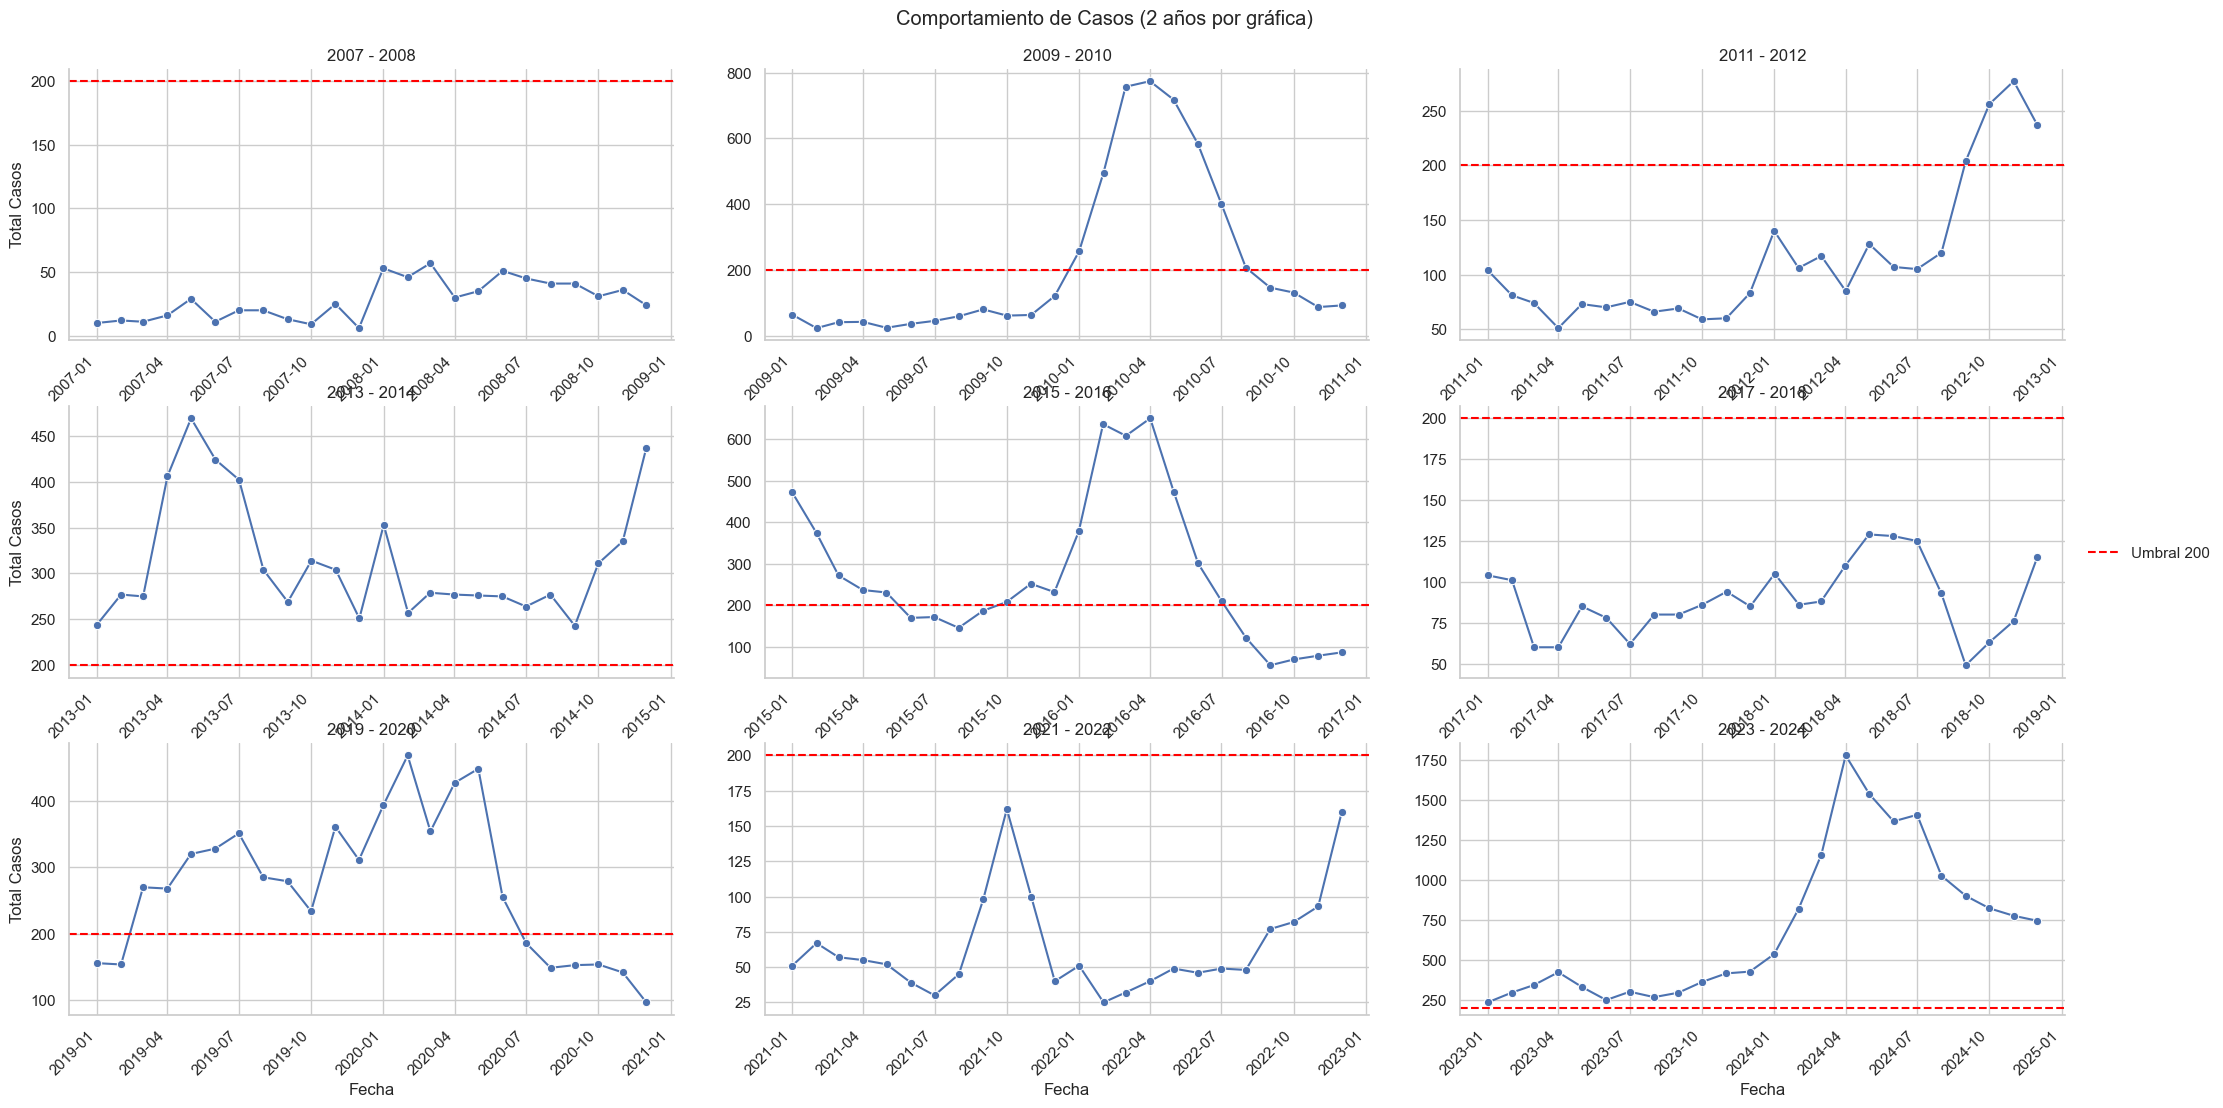

In [19]:
frecuencia_mensual_con_umbral_v2(df_cund, umbral=200, anos_por_subplot=2)

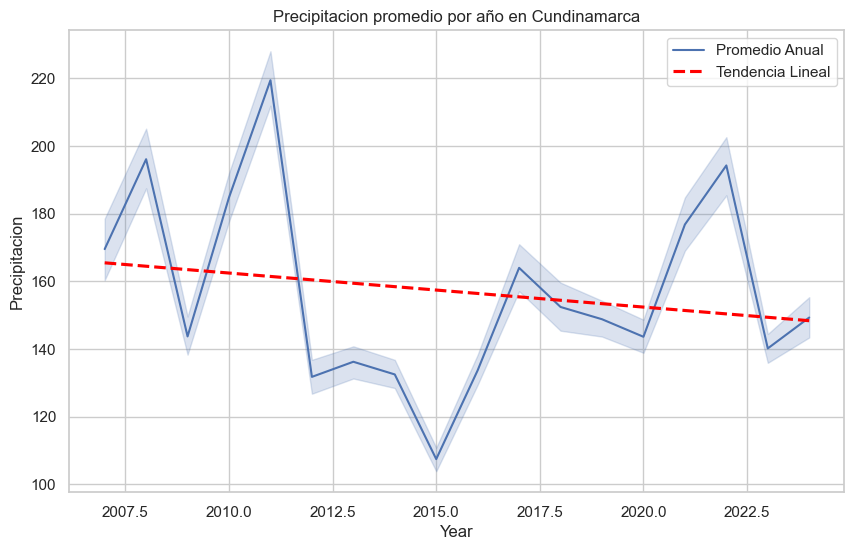

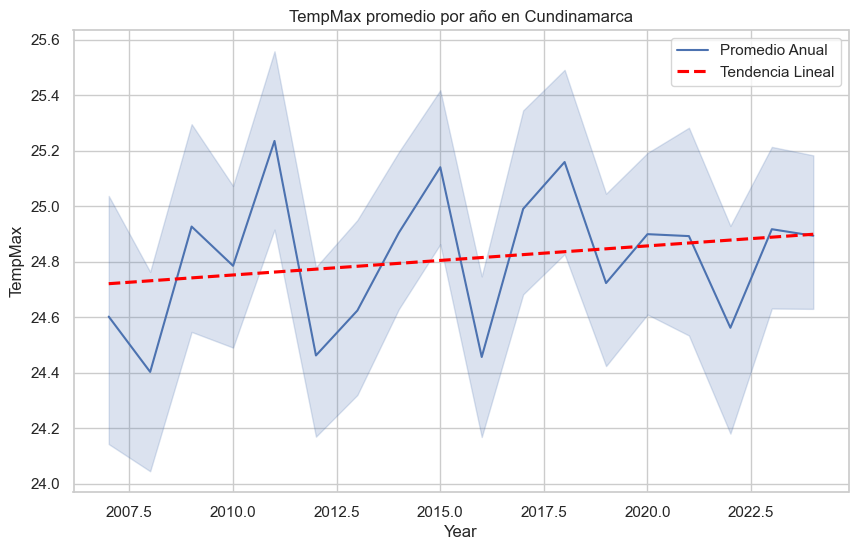

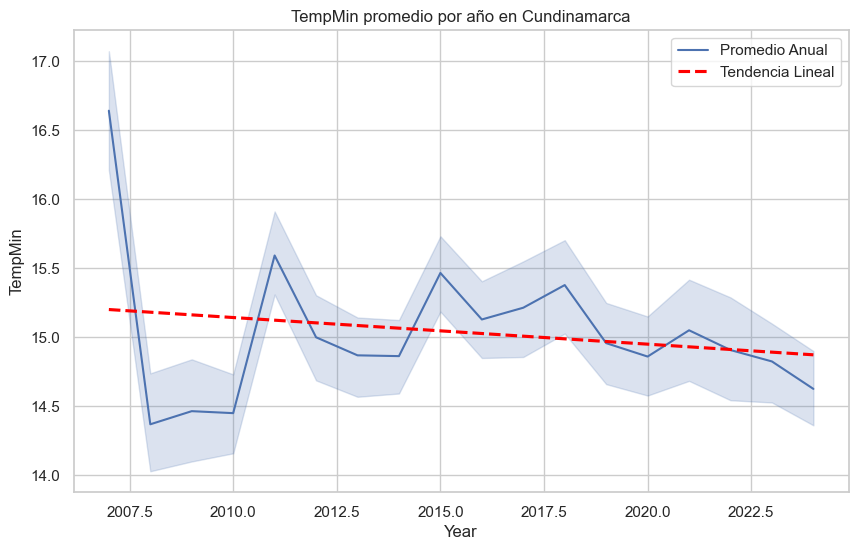

In [20]:
#* temperaturas y precipitacion promedio por año
cols = ['Precipitacion','TempMax','TempMin']
for col in cols:
    plt.figure(figsize=(10, 6))
    
    # 1. Tu gráfica original (Línea de promedios anuales)
    sns.lineplot(data=df_cund, x='Year', y=col, estimator='mean', label='Promedio Anual')
    
    # 2. Preparar datos para la tendencia (Agrupamos por año para obtener el promedio)
    # Esto es necesario porque lineplot agrega internamente, pero para calcular la tendencia
    # necesitamos los puntos exactos (x, y) de esos promedios.
    df_trend = df_cund.groupby('Year')[col].mean().reset_index()
    
    # 3. Graficar la línea de tendencia usando regplot
    # scatter=False evita que pinte los puntos de nuevo, solo queremos la línea
    # ci=None quita la sombra del intervalo de confianza (opcional, puedes dejarlo si prefieres)
    sns.regplot(data=df_trend, x='Year', y=col, scatter=False, color='red', line_kws={'linestyle':'--'}, label='Tendencia Lineal', ci=None)
    
    plt.title(f'{col} promedio por año en Cundinamarca')
    plt.legend()
    plt.show()


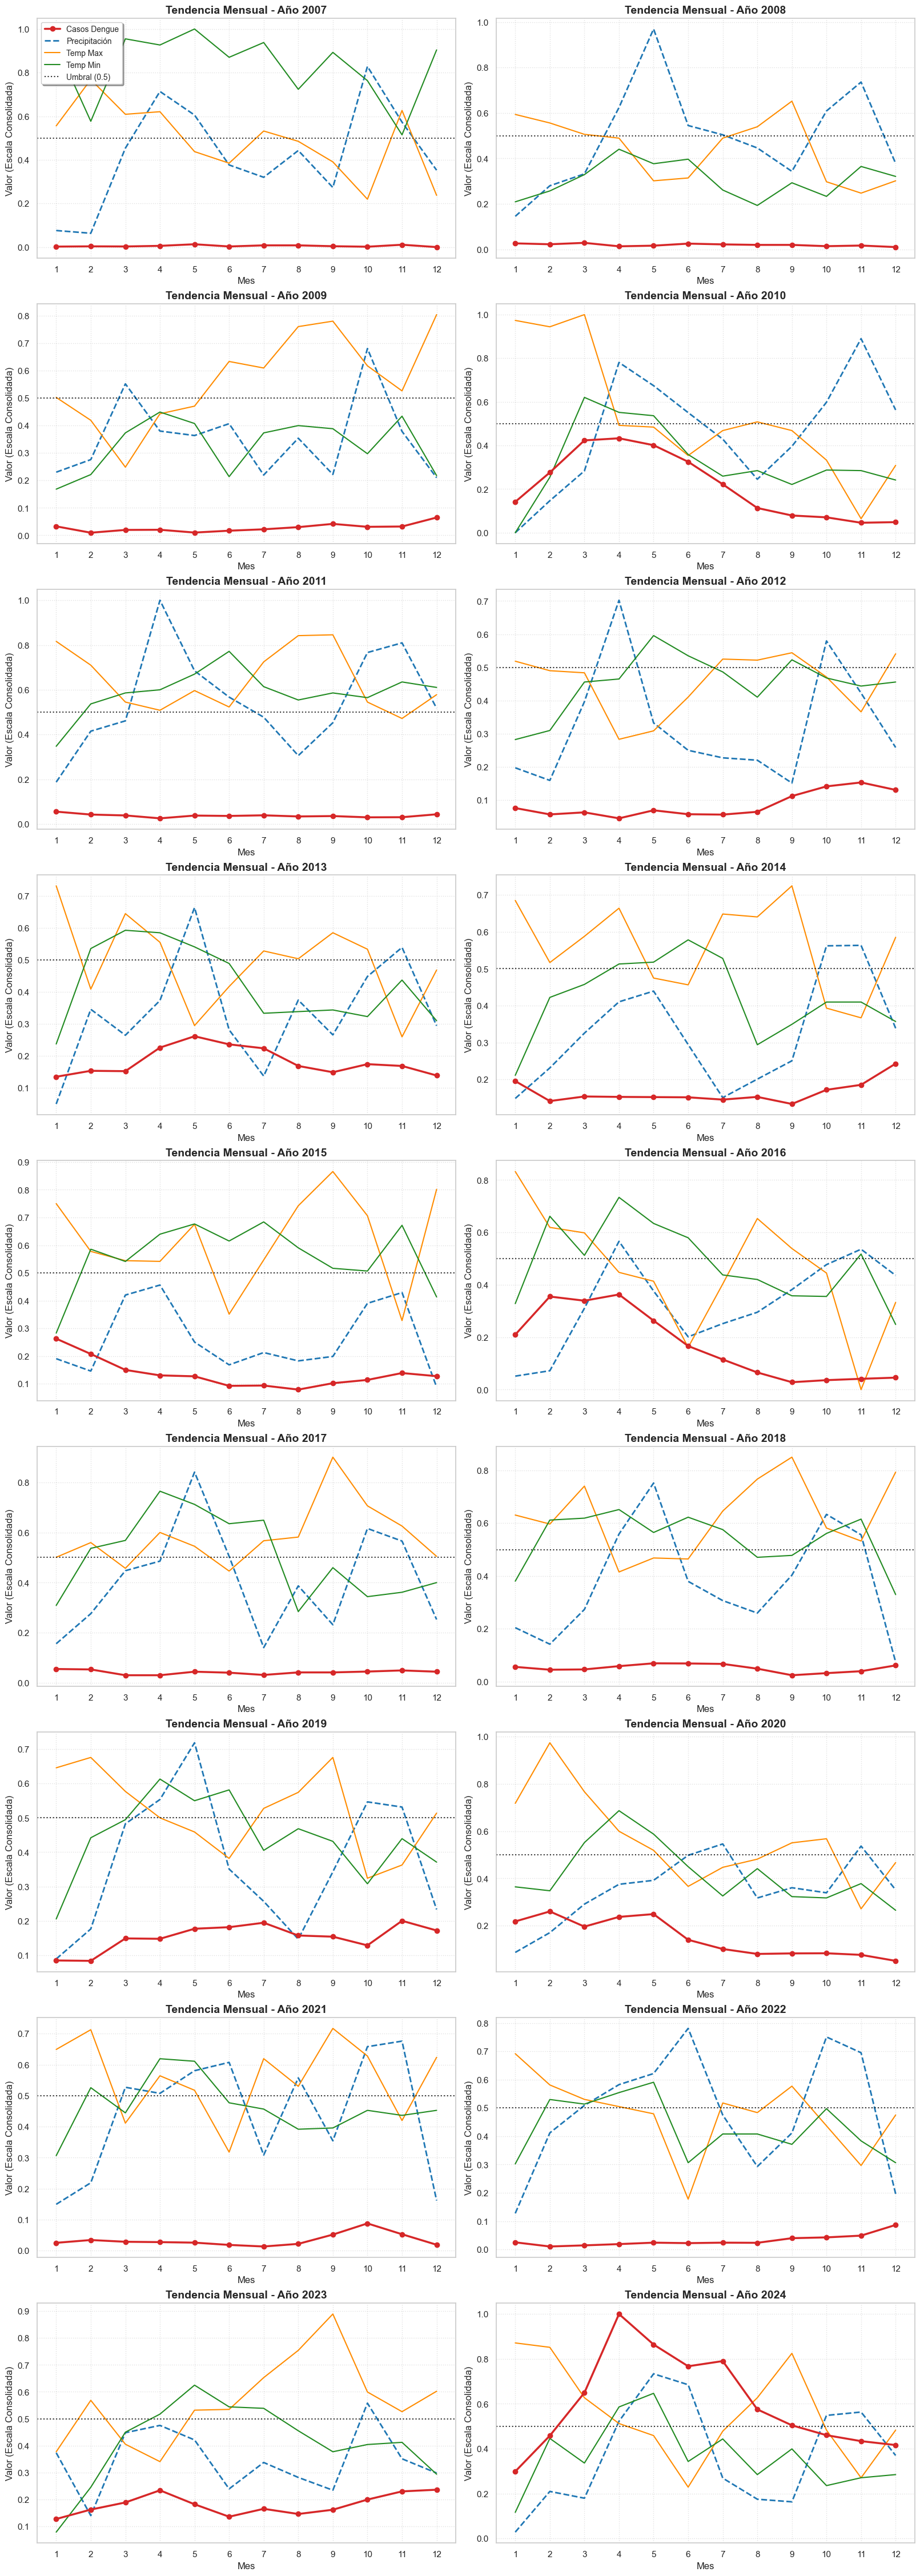

In [35]:
# df cundinamarca, agregado suma de casos confirmados y promedio de precipitacion, tempmax y tempmin por año, mes
df_cund_agrupado = df_cund.groupby(['Year', 'Mes']).agg({
    'CasosConfirmados': 'sum',
    'Precipitacion': 'mean',
    'TempMax': 'mean',
    'TempMin': 'mean'
}).reset_index()

# normalizar casos confirmados, precipitacion, tempmax y tempmin usando min max scaler
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_cund_agrupado[['CasosConfirmados', 'Precipitacion', 'TempMax', 'TempMin']] = scaler.fit_transform(df_cund_agrupado[['CasosConfirmados', 'Precipitacion', 'TempMax', 'TempMin']])
import pandas as pd
import matplotlib.pyplot as plt
import math

def graficar_seguimiento_anual_consolidado(df, umbral=None):
    """
    Genera una cuadrícula de gráficos por año con Casos, Precipitación y Temperaturas
    compartiendo el mismo eje Y para una comparación directa de magnitudes.
    """
    # 1. Procesamiento de datos
    df_plot = df.copy()
    # Aseguramos que el mes sea numérico para el correcto ordenamiento y visualización
    df_plot['Mes'] = df_plot['Mes'].astype(int)
    
    # Agrupamos por Año y Mes para obtener la suma de casos y el promedio de variables climáticas
    df_resumen = df_plot.groupby(['Year', 'Mes']).agg({
        'CasosConfirmados': 'sum',
        'Precipitacion': 'mean',
        'TempMax': 'mean',
        'TempMin': 'mean'
    }).reset_index().sort_values(['Year', 'Mes'])

    years = sorted(df_resumen['Year'].unique())
    n_years = len(years)
    cols = 2
    rows = math.ceil(n_years / cols)
    
    # 2. Creación de la figura
    fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows), constrained_layout=True)
    
    # Aseguramos que axes sea una lista incluso si hay un solo año
    if n_years == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, year in enumerate(years):
        ax = axes[i]
        data_year = df_resumen[df_resumen['Year'] == year]
        
        # --- PLOTEO DE TODAS LAS VARIABLES EN EL EJE ÚNICO ---
        # Casos Confirmados (Línea roja destacada con puntos)
        ax.plot(data_year['Mes'], data_year['CasosConfirmados'], 
                color='tab:red', marker='o', linewidth=2.5, label='Casos Dengue', zorder=5)
        
        # Precipitación (Línea azul discontinua)
        ax.plot(data_year['Mes'], data_year['Precipitacion'], 
                color='tab:blue', linestyle='--', linewidth=2, label='Precipitación')
        
        # Temperatura Máxima (Línea naranja)
        ax.plot(data_year['Mes'], data_year['TempMax'], 
                color='darkorange', linewidth=1.5, label='Temp Max')
        
        # Temperatura Mínima (Línea verde)
        ax.plot(data_year['Mes'], data_year['TempMin'], 
                color='forestgreen', linewidth=1.5, label='Temp Min')

        # 3. Configuración de ejes y estilos
        ax.set_title(f'Tendencia Mensual - Año {year}', fontsize=14, fontweight='bold')
        ax.set_xlabel('Mes')
        ax.set_ylabel('Valor (Escala Consolidada)')
        ax.set_xticks(range(1, 13)) # Forzar etiquetas de los 12 meses
        ax.grid(True, linestyle=':', alpha=0.6)

        # Umbral de alerta (si se proporciona)
        if umbral is not None:
            ax.axhline(y=umbral, color='black', linestyle=':', linewidth=1.5, 
                       label=f'Umbral ({umbral})', alpha=0.8)

        # Mostrar leyenda solo en el primer panel para no sobrecargar
        if i == 0:
            ax.legend(loc='upper left', fontsize='small', frameon=True, shadow=True)

    # Eliminar espacios vacíos si el número de años no completa la última fila
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.show()

# Ejemplo de uso con tus datos:
# graficar_seguimiento_anual_consolidado(df, umbral=0.5)
graficar_seguimiento_anual_consolidado(df_cund_agrupado, umbral=0.5)

In [30]:
df_cund_agrupado

,Year,Mes,CasosConfirmados,Precipitacion,TempMax,TempMin
0,2007,01,0.002255,0.075916,0.555782,0.926636
1,2007,02,0.003382,0.063410,0.768198,0.576744
2,2007,03,0.002818,0.453462,0.608886,0.954853
3,2007,04,0.005637,0.713533,0.620687,0.926636
4,2007,05,0.012965,0.605333,0.437774,1.000000
...,...,...,...,...,...,...
211,2024,08,0.574972,0.174568,0.626826,0.284313
212,2024,09,0.503946,0.162993,0.824758,0.398834
213,2024,10,0.459977,0.548160,0.482653,0.235232
214,2024,11,0.433484,0.563104,0.270059,0.270290


In [36]:
df_cund

,CodigoMunicipio,Departamento,Municipio,TipoMunicipio,Longitud,Latitud,Year,Mes,CasosConfirmados,Elevacion,Precipitacion,TempMax,TempMin
5610,25001,cundinamarca,agua de dios,municipio,-74.669221,4.375309,2007,01,0.0,343,43.299999,32.0,24.0
5611,25001,cundinamarca,agua de dios,municipio,-74.669221,4.375309,2008,01,3.0,343,70.500000,33.0,21.0
5612,25001,cundinamarca,agua de dios,municipio,-74.669221,4.375309,2009,01,1.0,343,104.099998,33.0,22.0
5613,25001,cundinamarca,agua de dios,municipio,-74.669221,4.375309,2010,01,3.0,343,8.200000,36.0,21.0
5614,25001,cundinamarca,agua de dios,municipio,-74.669221,4.375309,2011,01,0.0,343,80.900002,34.0,21.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
170962,25899,cundinamarca,zipaquira,municipio,-73.994444,5.025477,2020,12,1.0,2578,82.800003,20.0,9.0
170963,25899,cundinamarca,zipaquira,municipio,-73.994444,5.025477,2021,12,0.0,2578,38.299999,20.0,9.0
170964,25899,cundinamarca,zipaquira,municipio,-73.994444,5.025477,2022,12,1.0,2578,50.000000,20.0,8.0
170965,25899,cundinamarca,zipaquira,municipio,-73.994444,5.025477,2023,12,0.0,2578,76.900002,21.0,9.0
